# 🏋️‍♂️ModelFitness Churn Prediction

## 1. Cargar Librerías y Dataset

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, precision_score, recall_score 

In [5]:
df = pd.read_csv('datasets/gym_churn_us.csv')

## 2. Análisis Exploratorio de Datos (EDA)

In [6]:
# Análisis inicial
print(df.info())
print()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [7]:
# Corregir nombres columnas
columns_names = df.columns
new_columns_names = []
for name in columns_names.to_list():
    new_columns_names.append(name.lower().strip())

df.columns = new_columns_names 
df.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='str')

In [8]:
# ¿contiene alguna característica ausente? utiliza el método describe()
print(df.describe())

# Observa las medias de las características en dos grupos:
# personas que se fueron (cancelación) y las que se quedaron. groupby()
print('\nCaracterísticas promedio de los usuarios que cancelaron (1) y los que no (0)')
df.groupby('churn').mean()

            gender  near_location      partner  promo_friends        phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       contract_period  group_visits          age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


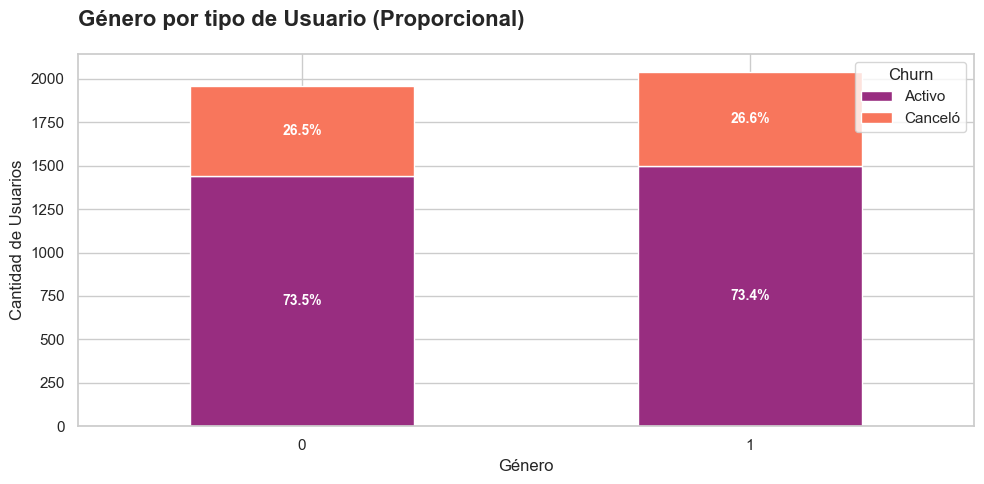

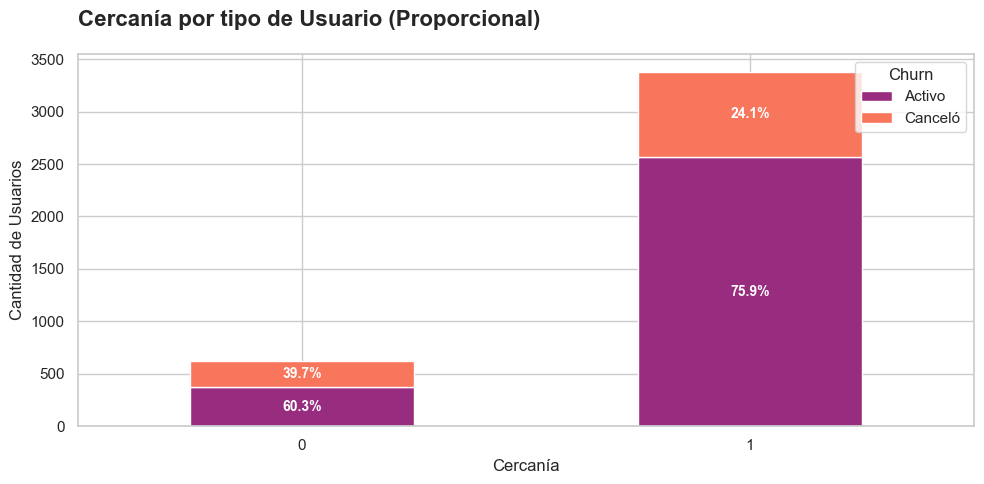

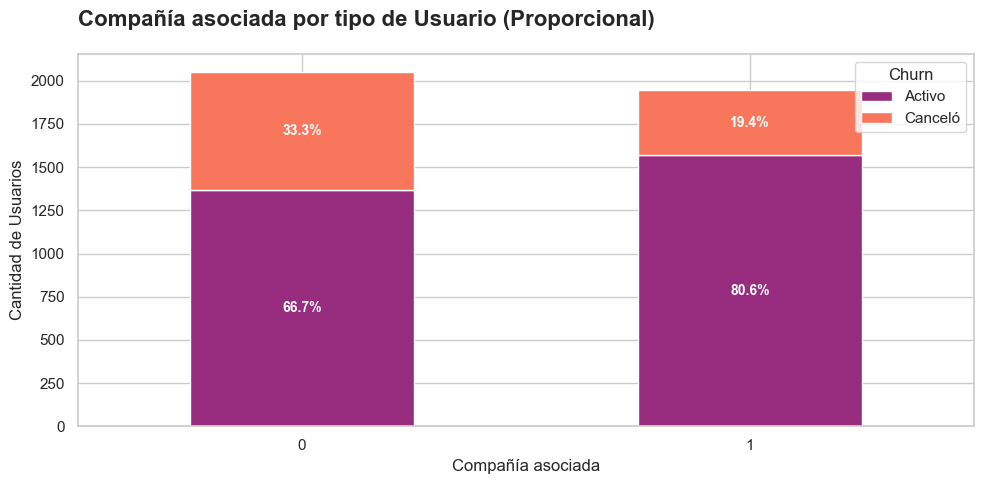

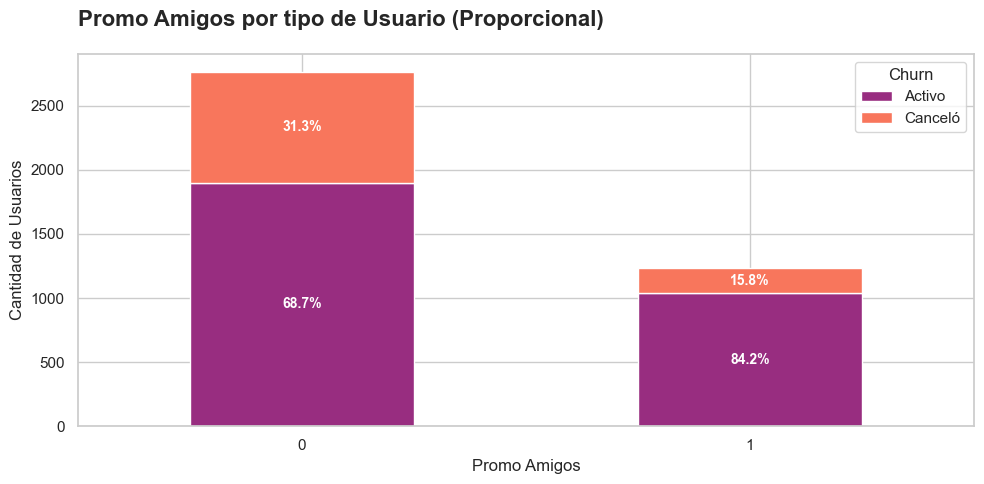

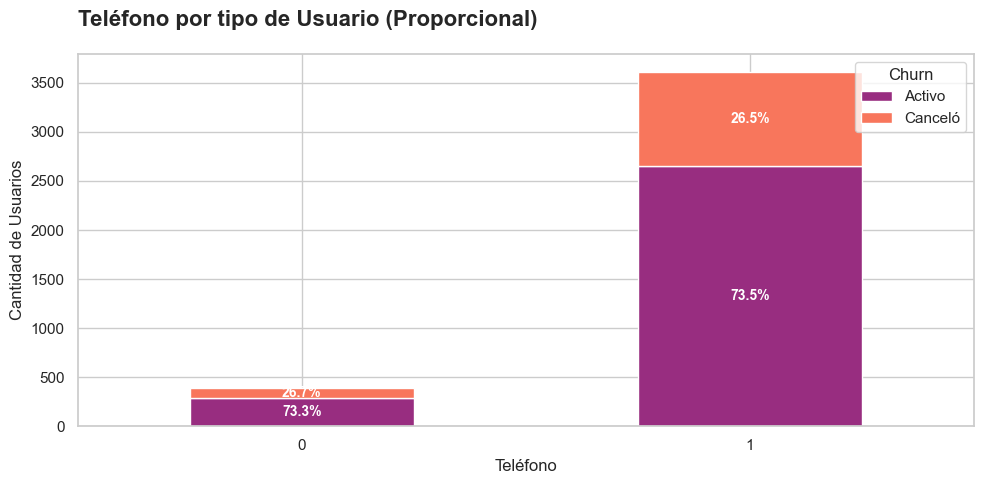

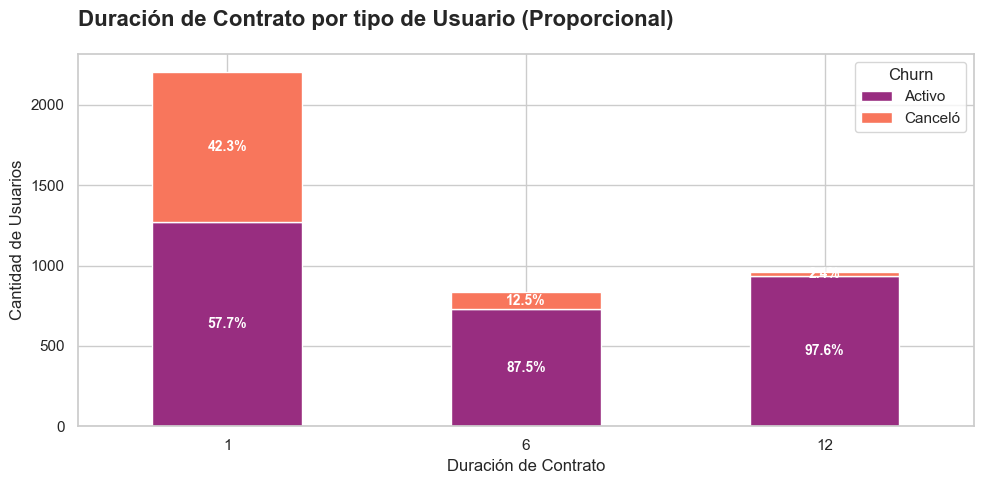

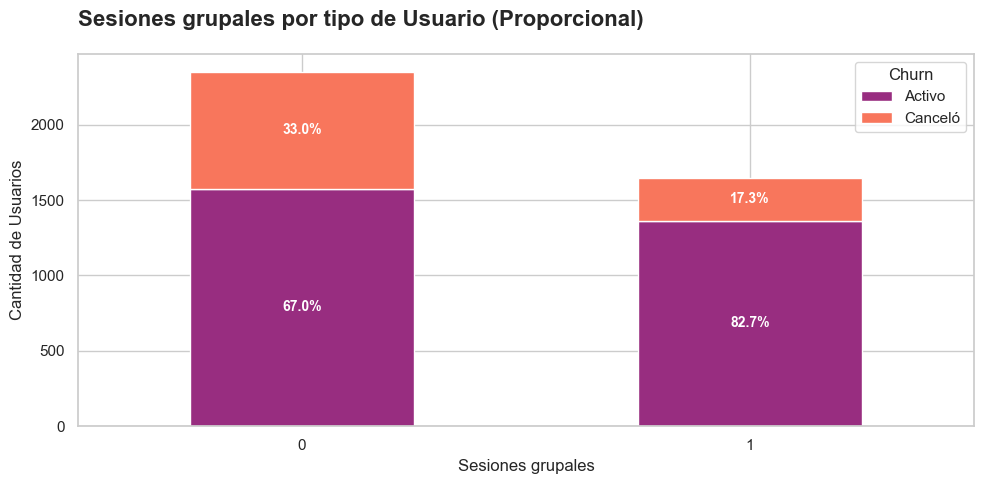

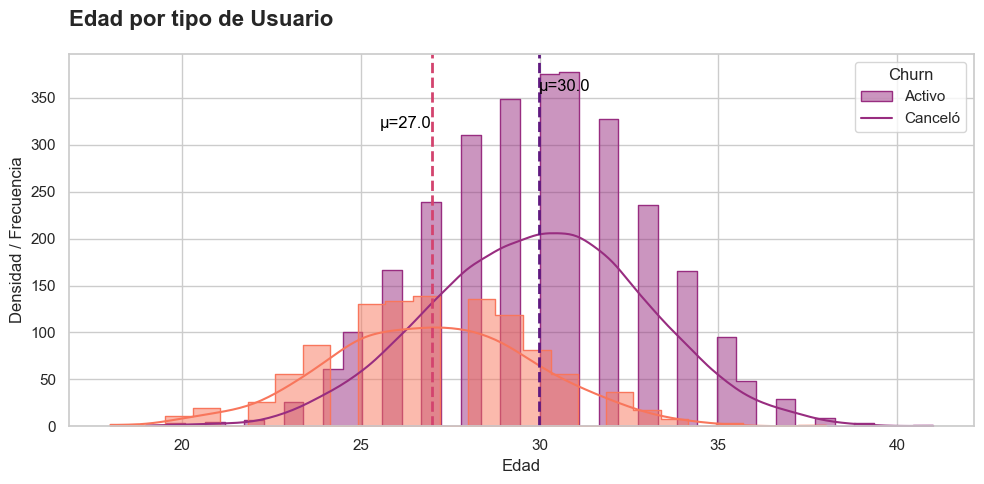

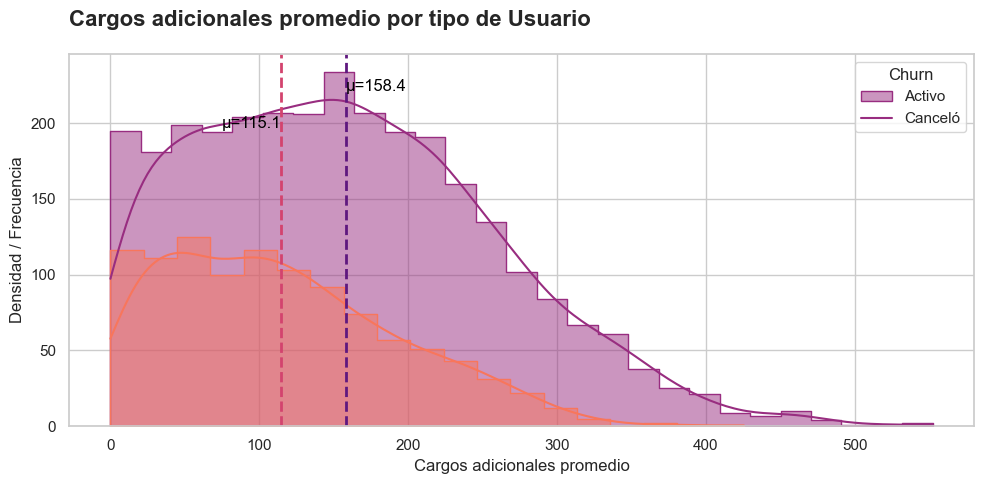

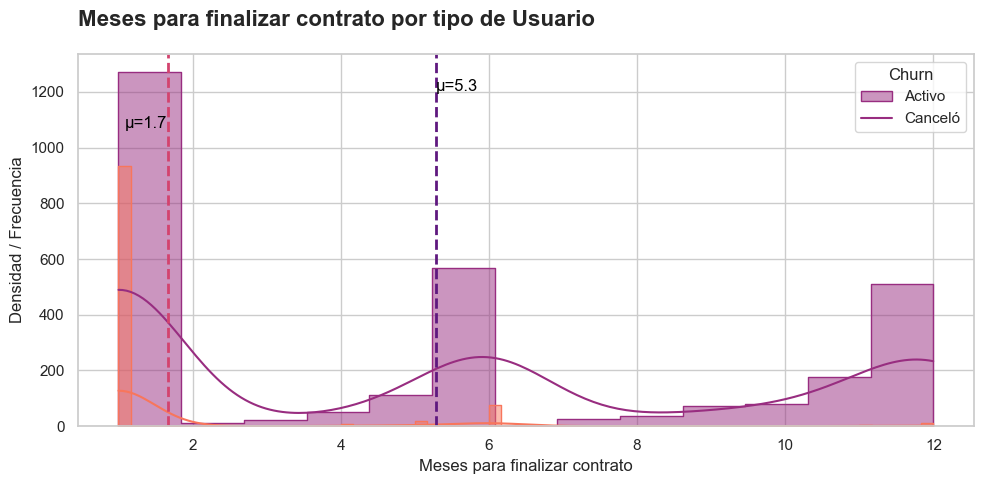

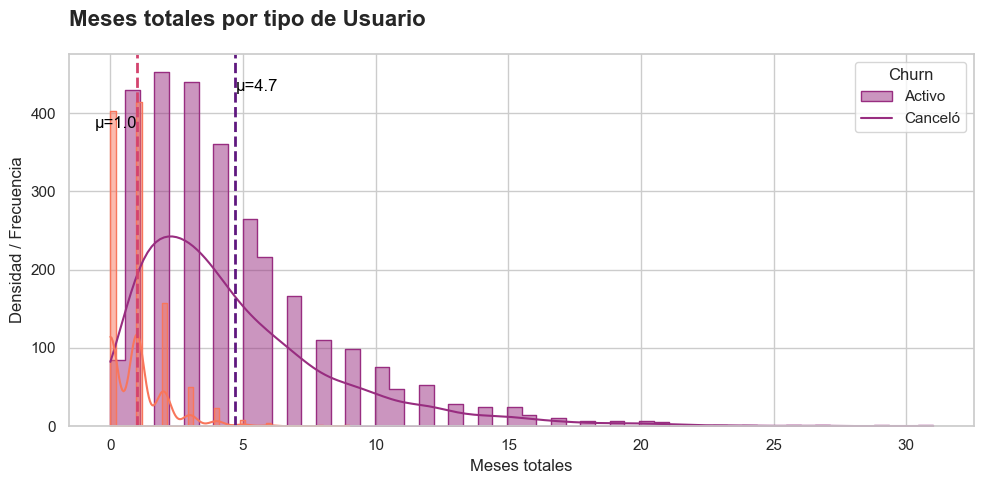

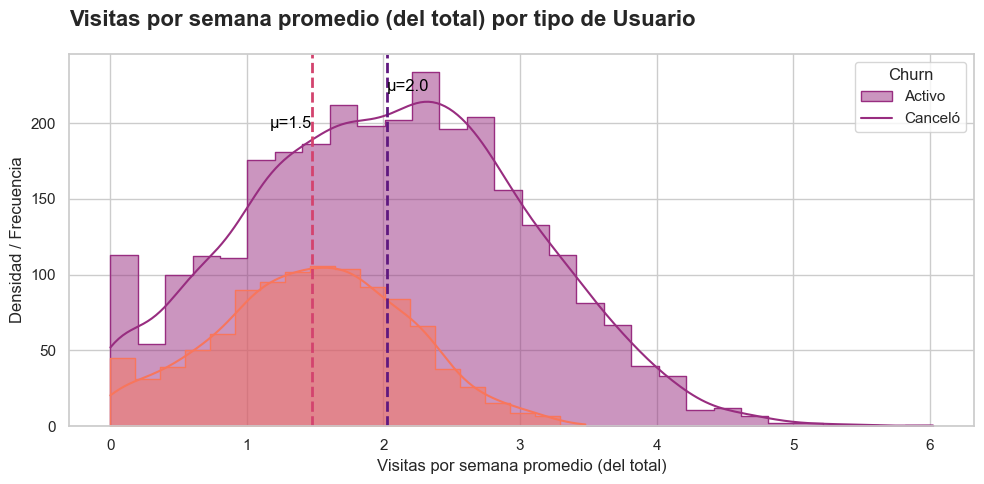

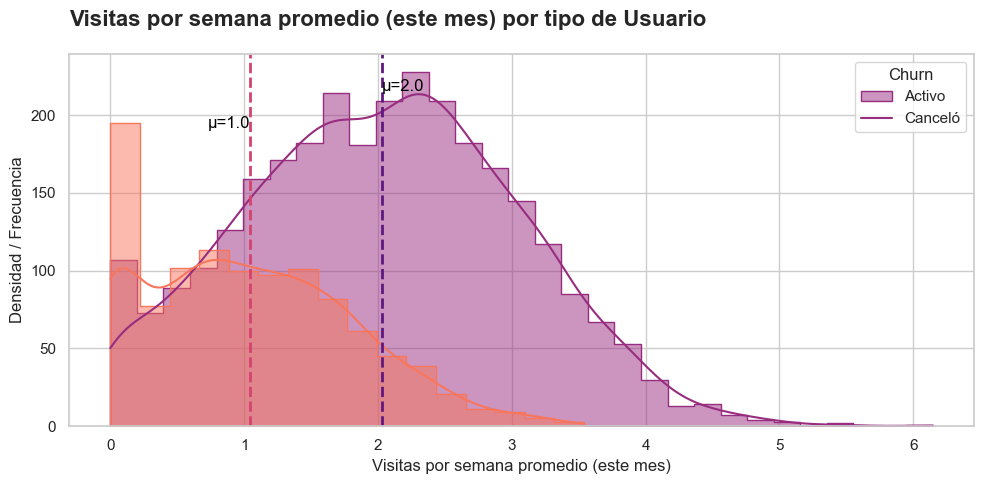

In [9]:
# Paleta de colores para los gráficos (palette 'magma' de sns)
color_1 = '#221150'
color_2 = '#5f187f'
color_3 = '#982d80'
color_4 = '#d3436e'
color_5 = '#f8765c'
color_6 = '#febb81'

# Crear 2 dataframes separados por cancelacion
active_users = df[df['churn'] == 0]
churned_users = df[df['churn'] == 1]

# Traza histogramas de barras y distribuciones de características para ambos grupos
# Crear un diccionario con los titulos para las graficas
chart_name = {
    new_columns_names[0] : 'Género',
    new_columns_names[1] : 'Cercanía',
    new_columns_names[2] : 'Compañía asociada',
    new_columns_names[3] : 'Promo Amigos',
    new_columns_names[4] : 'Teléfono',
    new_columns_names[5] : 'Duración de Contrato',
    new_columns_names[6] : 'Sesiones grupales',
    new_columns_names[7] : 'Edad',
    new_columns_names[8] : 'Cargos adicionales promedio',
    new_columns_names[9] : 'Meses para finalizar contrato',
    new_columns_names[10] : 'Meses totales',
    new_columns_names[11] : 'Visitas por semana promedio (del total)',
    new_columns_names[12] : 'Visitas por semana promedio (este mes)',
    new_columns_names[13] : 'Cancelación'
}

# Establecer el estilo del gráfico
sns.set_theme(style="whitegrid")

# Iterar la creación de los graficos
for col in new_columns_names:
    # Saltamos la columna 'churn' para no compararla consigo misma
    if col == 'churn':
        continue
    # Tamaño único para consistencia    
    plt.figure(figsize=(10, 5))

    # Condicion para decidir si crear histograma o grafico de barras
    if df[col].nunique() < 5:
        # Configuración para obtener los porcentajes
        counts = pd.crosstab(df[col], df['churn'])
        percentages = pd.crosstab(df[col], df['churn'], normalize='index') * 100

        # Crear gráfico y configurar formato
        ax = counts.plot(kind='bar', stacked=True, color=[color_3, color_5], ax=plt.gca())
        plt.title(f'{chart_name[col]} por tipo de Usuario (Proporcional)', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('Cantidad de Usuarios')
        plt.xticks(rotation=0)
        plt.legend(title='Churn', labels=['Activo', 'Canceló'], loc='upper right')

        # Iteración para colocar los porcentajes
        i = 0
        for c in counts.columns:
            for j, p in enumerate(ax.patches[i*len(counts):(i+1)*len(counts)]):
                pct = percentages.iloc[j, i]
                if p.get_height() > 0:
                    x = p.get_x() + p.get_width() / 2
                    y = p.get_y() + p.get_height() / 2
                    ax.annotate(f'{pct:.1f}%', (x, y), ha='center', va='center', 
                                color='white', fontweight='bold', fontsize=10)
            i += 1
            
    else:
        # Crear histograma
        sns.histplot(active_users, x=col, kde=True, element="step", color=color_3, label='Activo')
        sns.histplot(churned_users, x=col, kde=True, element="step", color=color_5, label='Canceló')
        
        mean_active = active_users[col].mean()
        mean_churned = churned_users[col].mean()
        
        # Crear linea y texto con la media
        plt.axvline(mean_active, color=color_2, linestyle='--', linewidth=2)
        plt.axvline(mean_churned, color=color_4, linestyle='--', linewidth=2)
        plt.text(mean_active, plt.ylim()[1]*0.9, f'μ={mean_active:.1f}', color='black',)
        plt.text(mean_churned, plt.ylim()[1]*0.8, f'μ={mean_churned:.1f}', color='black', ha='right')
        
        # Configuraciones de formato
        plt.title(f'{chart_name[col]} por tipo de Usuario', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('Densidad / Frecuencia')
        plt.legend(title='Churn', labels=['Activo', 'Canceló'])
    
    plt.tight_layout() # Ajusta automáticamente los márgenes para que no se corten etiquetas
    plt.show()

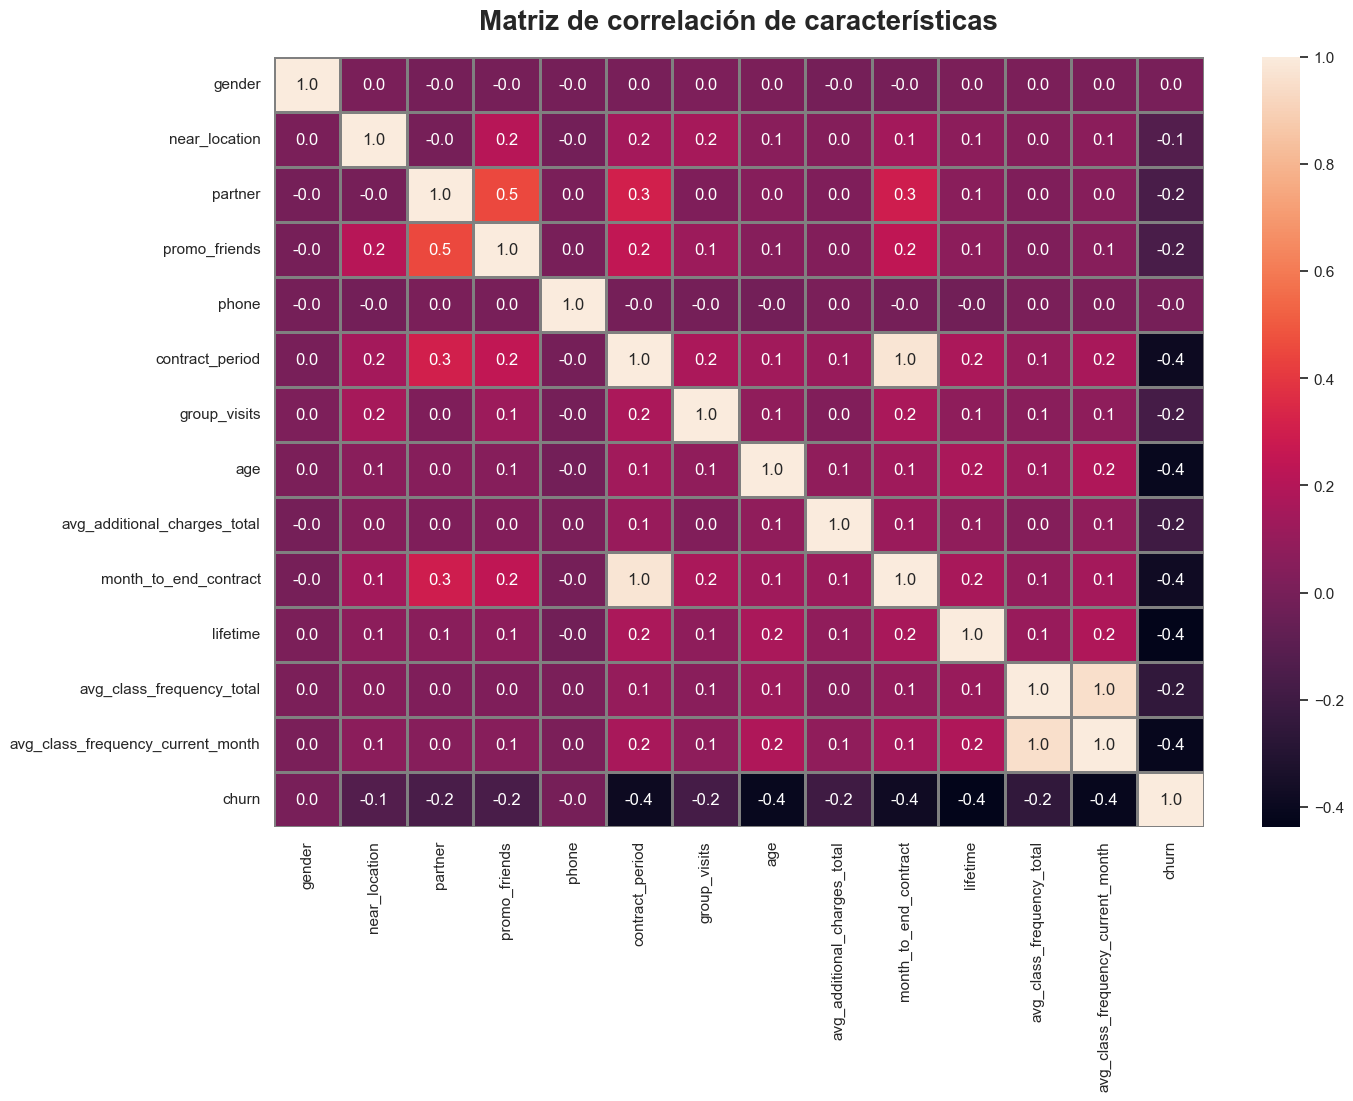

In [10]:
# Crea una matriz de correlación y muéstrala
# Declarar variable con la matriz de correlación
cm = df.corr()

# Crear mapa de calor para mostrar matriz
plt.figure(figsize=(15,10))
sns.heatmap(
    cm, 
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='gray'
)

# Configuracion de formato
plt.title('Matriz de correlación de características', fontweight='bold', fontsize=20, pad=20)
plt.show()

<b>CONCLUSIONES INTERMEDIAS:</b>

Observaciones de las graficas:

- Tanto el género 0 como el género 1 tienen el mismo porcentaje de usuarios activos y con cancelaciones.
- La proporción de usuarios que cancelaron su suscripción es 15% mas en el grupo que no vive o trabaja cerca del gimnasio.
- 14% más de cancelaciones en el grupo que su compañía no esta asociada al gimnasio.
- 15.5% más de cancelaciones en el grupo que no se inscribio con Promo Amigos.
- El tema del telefono no mostro diferencias significativas.
- 29.8% más cancelaciones entre los usuarios que su contrato es de 1 mes, que los de 6 meses, y 39.9 % más que los de 12 meses.
- 15.7% mas cancelaciones en el grupo que no asiste a sesiones grupales.
- La edad promedio de los usuarios que cancelan es menor (3 años) que los activos.
- Los usuarios que cancelaron tuvieron 27.33% menos gatos adicionales promedio.
- El promedio de meses para finalizar contrato de los usuarios que cancelaron fue 1.7; 3.6 meses menos que los usuarios activos.
- Los usuarios que cancelaron tuvieron en promedio 1 mes total de suscripción.
- Los usuarios que activos tienen en promedio 4.7 meses totales.
- Las visitas por semana (del total) difiere en 0.5 visitas entre los que cancelaron y los activos.
- Las visitas por semana (del mes) difiere en 1 visita entre los que cancelaron y los activos.

Matriz de Correlación:

- Las carracterísticas con más fuerte correlación fueron Duración de contrato y meses para finalizar el contrato (1.0), y 'Visitas promedio (del total)' y 'Visitas promedio (del mes) (1.0).
- La característica 'Género' tuvo una correlacion de 0 con todo el resto.
- Otras correlaciones importantes fueron 'Partner' y 'Promo Amigos' (0.5), 'Partner' y 'Duración del contrato' (0.3), 'Partner' y 'Meses para finalizar contrato' (0.3) 
- Relaciones negativas(inversamente proporcionales) importantes fueron 'Duración del contrato' y 'Churn' (-0.4), 'Edad' y 'Churn' (-0.4), 'Meses para finalizar' y 'Churn' (-0.4), 'Meses totales' y 'Churn' (-0.4) y 'Visitas promedio (del mes)' y 'Churn'.

## 3. Construir Modelo de Predicción

In [11]:
# Crea un modelo de clasificación binaria para clientes
# La característica objetivo es la marcha del usuario el mes siguiente

# Dividir características de variable objetivo
X = df.drop('churn', axis=1)
y = df['churn']

# Entrena el modelo con dos métodos, regresión lógistica y bosque aleatorio
lr_model = LogisticRegression()
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

# Definir función para correr modelos y pruebas
def predictive_model(model, X, y):
    # 1. Divide los datos con train_test_split()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # 2. Estandarizar datos
    sc = StandardScaler()
    X_train_sc = sc.fit_transform(X_train)
    X_test_sc = sc.transform(X_test)

    # 3. Entrentar modelo
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    # 4. Evaluar modelo
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score (y_test, y_pred)
    recall = recall_score (y_test, y_pred)

    # 5. Contabilizar predicciones
    churned = list(y_pred).count(1)

    # 6. Imprimir resultados
    model_name = model.__class__.__name__
    print('Modelo =', model_name)
    print('Predicción:')
    print(f'{churned} cancelaciones')
    print()
    print('Métricas del modelo:')
    print('Exactitud: {:.2f}'.format(acc))
    print('Precisión: {:.2f}'.format(precision))
    print('Recall: {:.2f}'.format(recall))

# Correr la funcion con los 2 modelos
predictive_model(lr_model, X, y)
print()
predictive_model(rf_model, X, y)

Modelo = LogisticRegression
Predicción:
192 cancelaciones

Métricas del modelo:
Exactitud: 0.92
Precisión: 0.85
Recall: 0.83

Modelo = RandomForestClassifier
Predicción:
192 cancelaciones

Métricas del modelo:
Exactitud: 0.92
Precisión: 0.84
Recall: 0.81


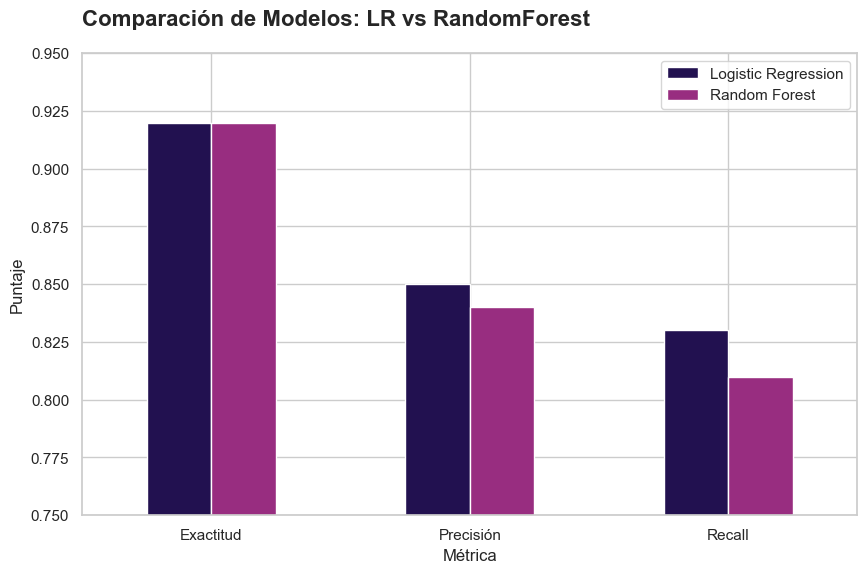

In [12]:
# Datos de tus resultados
data = {
    'Métrica': ['Exactitud', 'Precisión', 'Recall'],
    'Logistic Regression': [0.92, 0.85, 0.83],
    'Random Forest': [0.92, 0.84, 0.81]
}

df_results = pd.DataFrame(data)
df_results.set_index('Métrica').plot(kind='bar', figsize=(10, 6), rot=0, color=[color_1, color_3])

plt.title('Comparación de Modelos: LR vs RandomForest', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.ylabel('Puntaje')
plt.ylim(0.75, 0.95)
plt.legend(loc='upper right')
plt.show()

<b>CONCLUSIONES INTERMEDIAS:</b>

¿Qué modelo dio mejores resultados?

- Exactitud (Accuracy): 
    LR(0.92) vs RF(0.92), ambos modelos fueron igual de acertados.

- Precisión (Precision):
    LR(0.85) vs RF(0.84), la regresión lógistica tiene ligeramente menos falsos positivos, el bosque aleatorio detectará 1% más clientes de los que en realidad cancelarán.

- Recall (Sensibilidad):
    LR(0.83) vs RF(0.81), la regresión lógistica captura un mayor porcentaje (2%) de los clientes que realmente se van.

Considerando lo anterior, y el tipo de modelo de negocios de la cadena de gimnasios, `el mejor` modelo para la predicción en este caso es la `regresión lógistica`.

Ambos modelos estuvieron muy parejos en sus resultados, pero la `regresión logística` nos dará información ligeramente más certera de los clientes en los cuales hay que concentrarse e invertir dinero en estrategias de retención de clientes.

El modelo `Bosque Aleatorio` también dio muy buen resultado pero, se corre el riesgo de invertir dinero de más en falsos positivos (aunque sean pocos), lo que se traduciría en `fuga de dinero` por gastos de retención de clientes que no eran necesarias. Como el objetivo final de este estudio es incrementar los ingresos del gimnasio, este modelo no es el más adecuado.



## 4. Importancia de Características

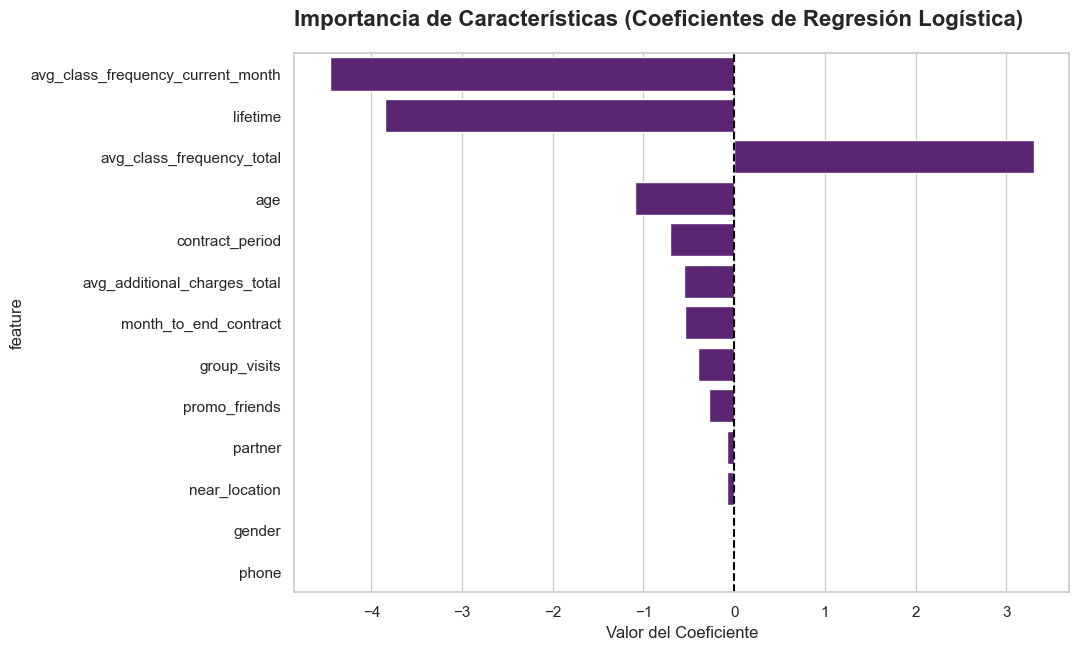

In [30]:
# Extraer coeficientes
coefficients = lr_model.coef_[0]

# Crear un DataFrame para visualizar
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'importance': coefficients,
    'abs_importance': np.abs(coefficients) # Usamos valor absoluto para el ranking
}).sort_values(by='abs_importance', ascending=False)

# Visualización
plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', data=feature_importance_lr, color=color_2)
plt.axvline(x=0, color='black', linestyle='--') # Línea en cero para separar lealtad vs churn
plt.title('Importancia de Características (Coeficientes de Regresión Logística)', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.xlabel('Valor del Coeficiente')
plt.show()

**NOTA:**

Se detectó multicolinealidad entre las variables de frecuencia. Se decidió eliminar una para mejorar la interpretabilidad de los coeficientes del modelo. En este caso se decidió conservar la frecuencia en el mes en curso ya que es la que se alimenta de información más reciente del cliente.

Modelo = LogisticRegression
Predicción:
207 cancelaciones

Métricas del modelo:
Exactitud: 0.90
Precisión: 0.79
Recall: 0.83


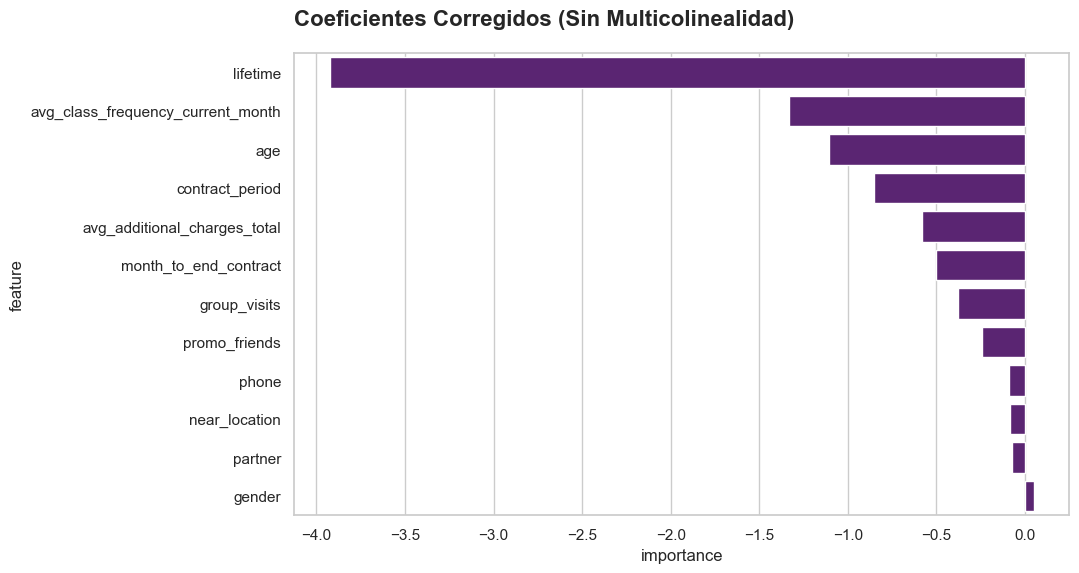

In [31]:
# Eliminar la frecuencia total para ver el impacto del mes actual
X_filtered = X.drop(['avg_class_frequency_total'], axis=1)

# Re-entrenamos el modelo
lr_model_clean = LogisticRegression(random_state=42)

predictive_model(lr_model_clean, X_filtered, y)

# Graficamos de nuevo los coeficientes
coefficients_clean = lr_model_clean.coef_[0]
feature_importance_clean = pd.DataFrame({
    'feature': X_filtered.columns,
    'importance': coefficients_clean
}).sort_values(by='importance')

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_clean, color=color_2)
plt.title('Coeficientes Corregidos (Sin Multicolinealidad)', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.show()

**CONLCUSIONES INTERMEDIAS:**

- Aunque el modelo de Random Forest muestra una precisión ligeramente superior, se optó por la Regresión Logística (tras corregir la multicolinealidad) debido a que mantiene el Recall más alto (0.83). En un contexto de retención, priorizamos identificar a la mayor cantidad posible de clientes en riesgo de abandono.
- La variable promedio de visitas semanales (del mes) es uno de los predictores más fuertes. Esto confirma que la asistencia del último mes es el "termómetro" real del cliente; una disminución en la frecuencia semanal es una señal de alerta inmediata antes del abandono definitivo.
- Existe una relación inversa clara entre el tiempo que el cliente lleva en el gimnasio y la probabilidad de churn. Los clientes que superan los primeros meses críticos desarrollan un hábito que los hace mucho más leales, lo que sugiere que los esfuerzos de retención deben concentrarse en los "primeros pasos" del usuario.
- La ubicación física sigue siendo un factor determinante. Los clientes que viven o trabajan cerca tienen una barrera de salida mucho menor. Esto valida que la conveniencia logística es un pilar de la retención para ModelFitness.
- El modelo muestra que los clientes de mayor edad tienden a tener tasas de abandono más bajas. Esto puede indicar una mayor estabilidad en sus rutinas o un compromiso más sólido con sus objetivos de salud en comparación con los perfiles más jóvenes.
- La variable gender (género) muestra un coeficiente cercano a cero, es decir el abandono no discrimina por género.

## 5. Crear Clústeres de Usuarios

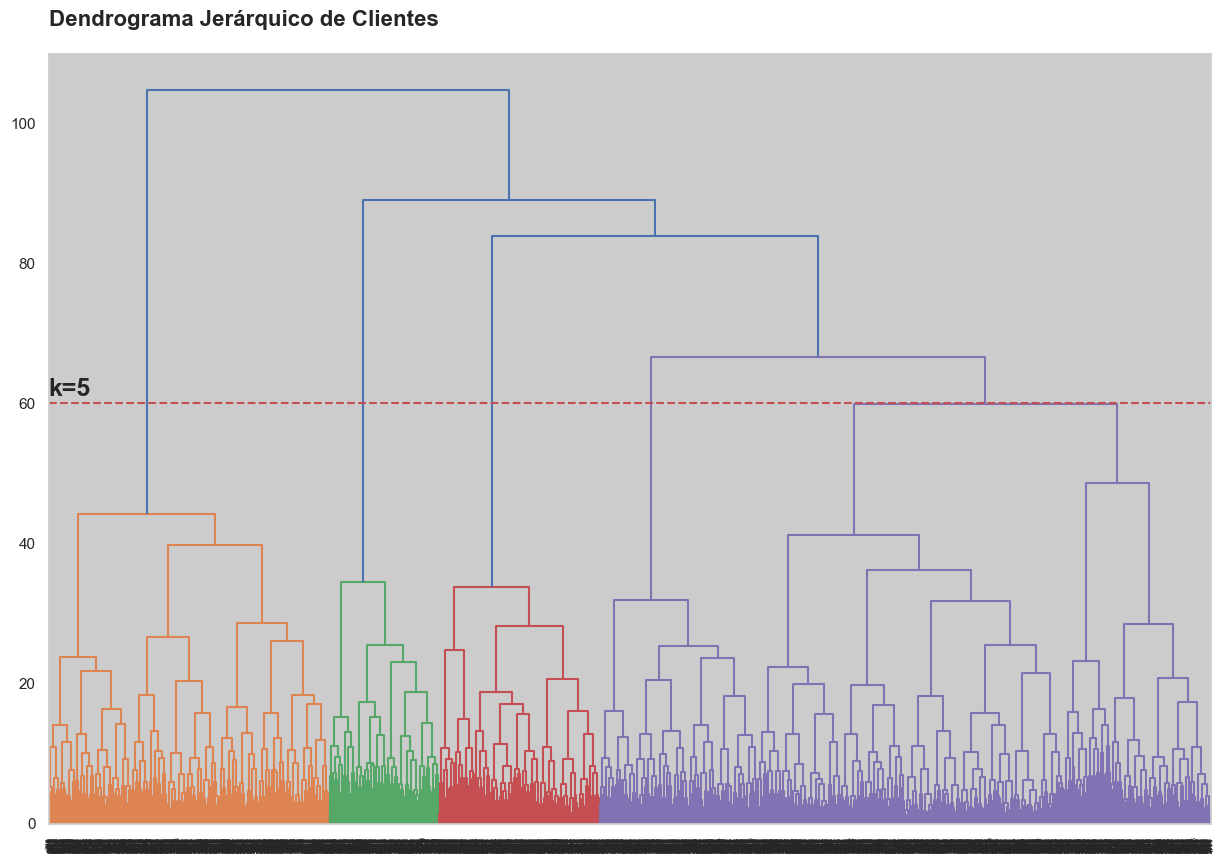

In [39]:
# Deja de lado la columna con datos sobre la cancelación e identifica los clústeres
# Estandariza los datos
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada
Z = linkage(X_sc, 'ward')

# trazar un dendrograma
plt.figure(figsize=(15, 10))
dendrogram(Z)
plt.title('Dendrograma Jerárquico de Clientes', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.axhline(y=60, color='r', linestyle='--')
plt.text(0, 61, 'k=5', fontweight='bold', fontsize=18)
plt.show()


In [14]:
# Entrena el modelo de clustering con el algortimo K-means
# (Deja que el número de clústeres sea n=5)
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_sc)

# Mira los valores medios de característica para los clústeres.
df['cluster'] = labels
df.groupby('cluster').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.486819,1.000000,0.243409,0.007030,0.899824,1.978910,0.326889,28.239016,130.877033,1.896309,2.477153,1.318003,1.083831,0.513181
1,0.592493,0.970509,0.288204,0.123324,0.898123,2.898123,0.482574,30.339142,164.193829,2.654155,5.219839,2.937411,2.944131,0.054960
2,0.499469,0.943677,0.740701,0.489904,0.900106,11.866100,0.551541,29.905420,165.146492,10.852285,4.737513,1.989423,1.980764,0.022317
3,0.483360,1.000000,0.798732,1.000000,0.911252,3.079239,0.445325,29.052298,139.858265,2.873217,3.510301,1.665722,1.547717,0.269414
4,0.496324,0.000000,0.466912,0.077206,0.915441,2.209559,0.215074,28.483456,133.630215,2.073529,2.781250,1.657657,1.466870,0.450368


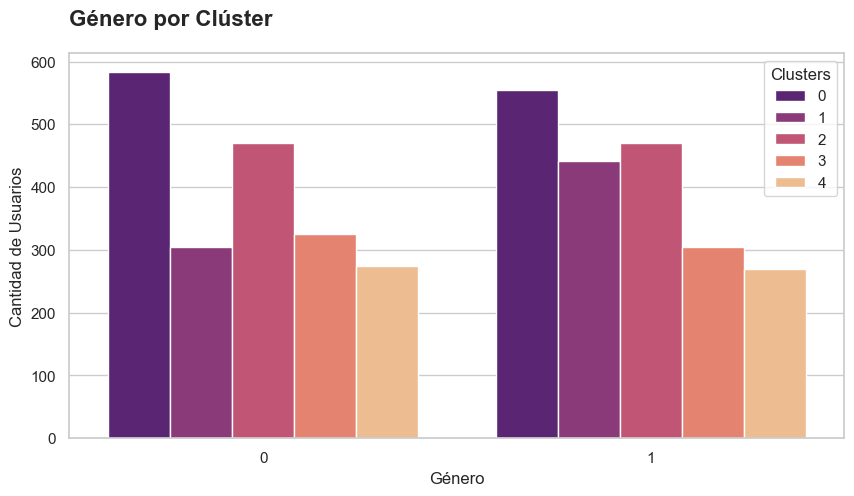

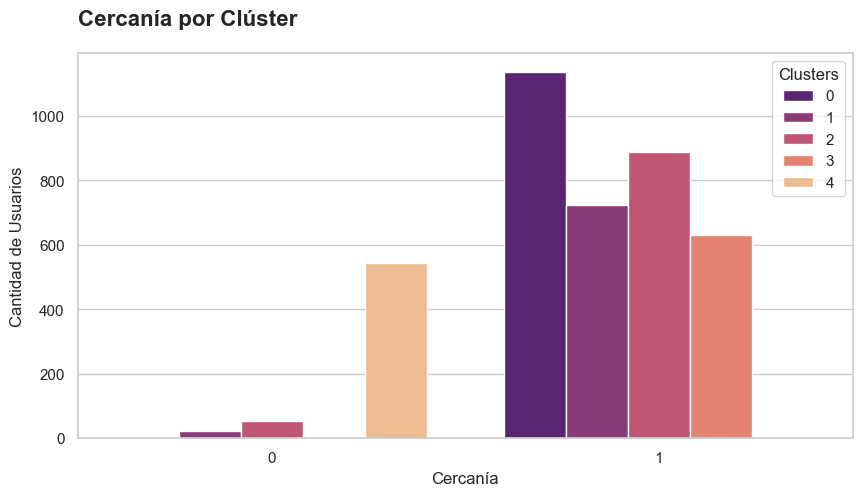

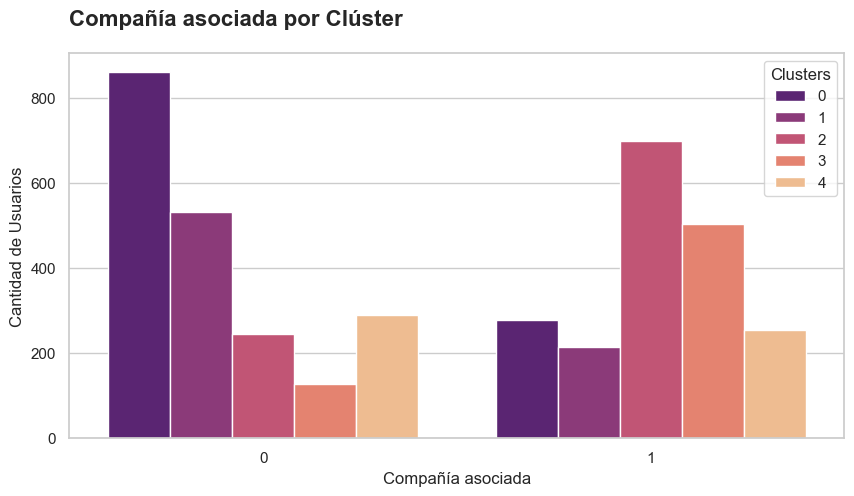

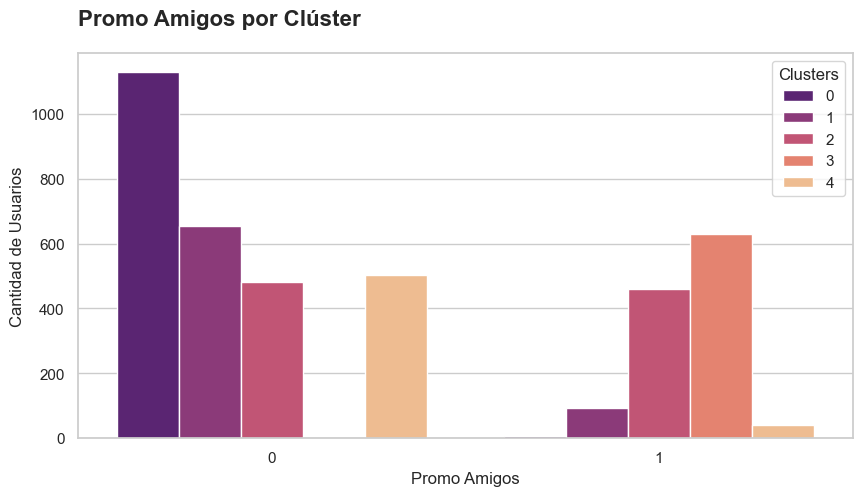

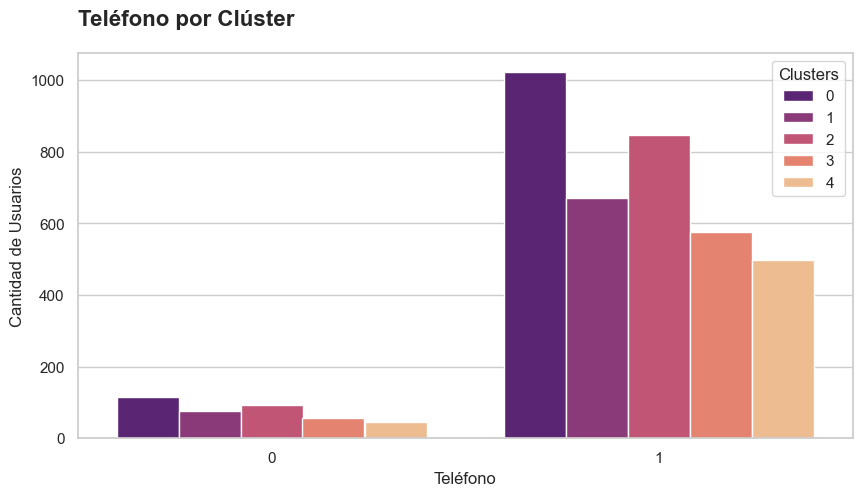

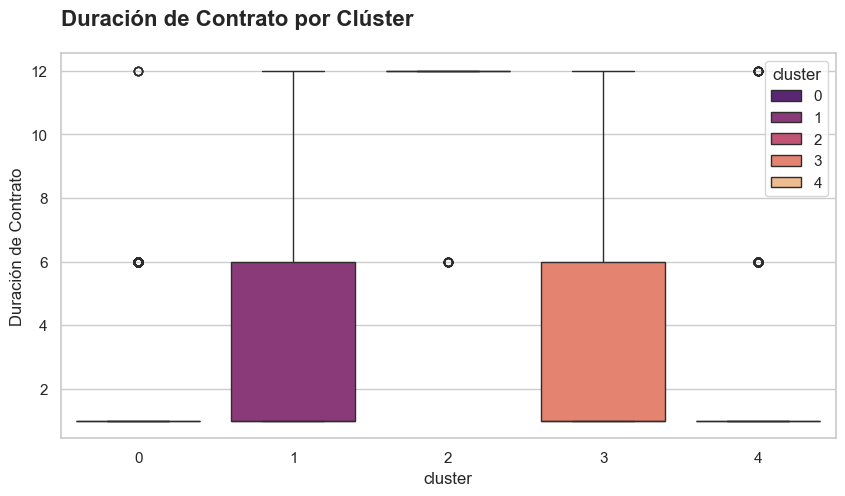

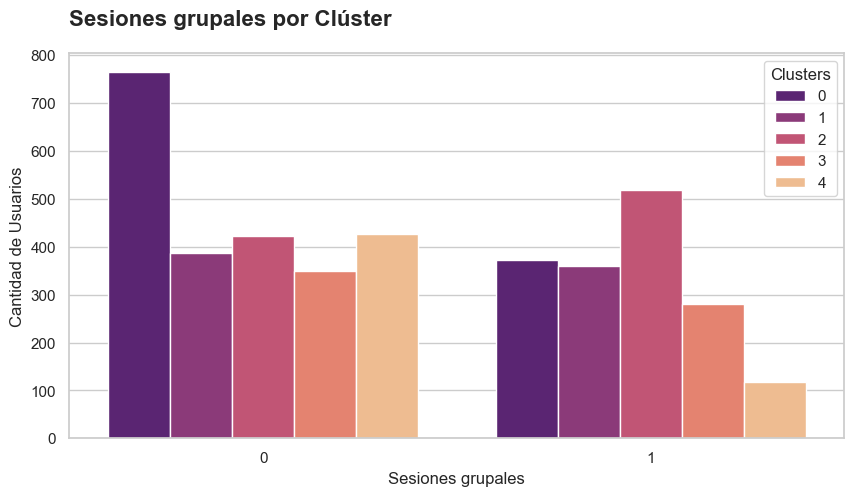

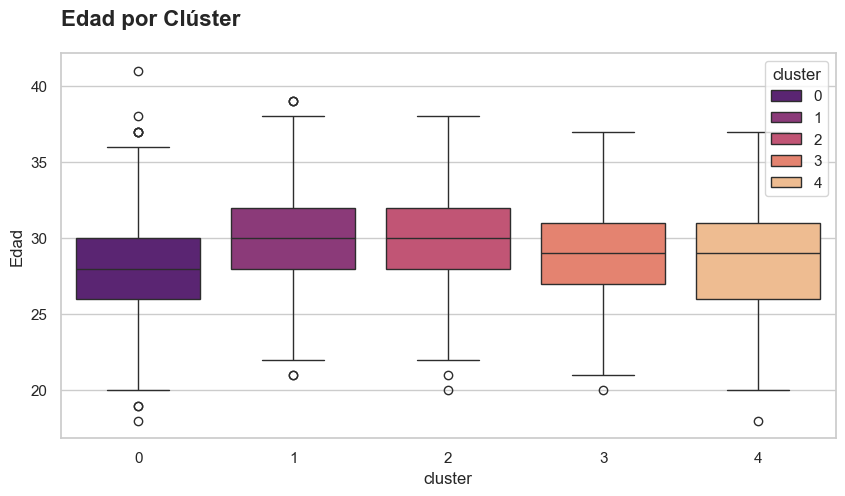

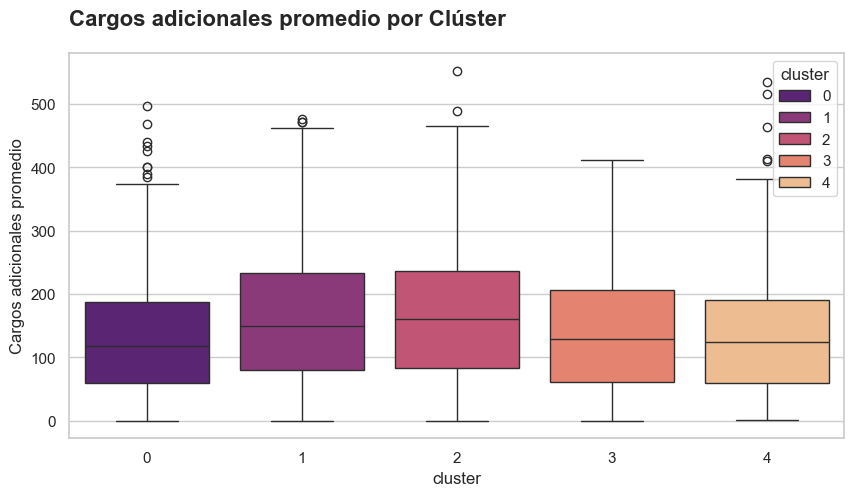

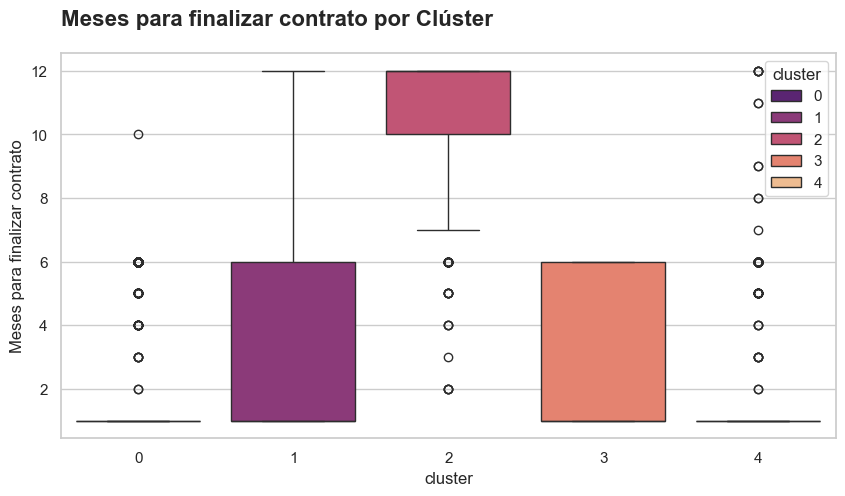

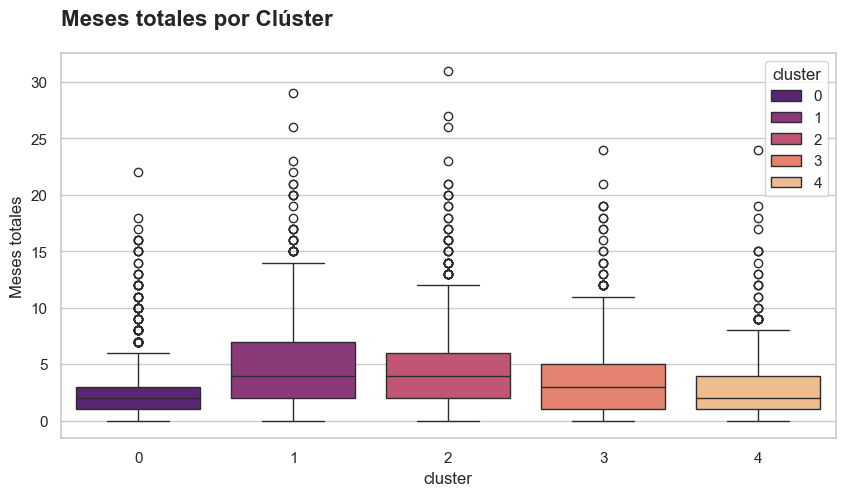

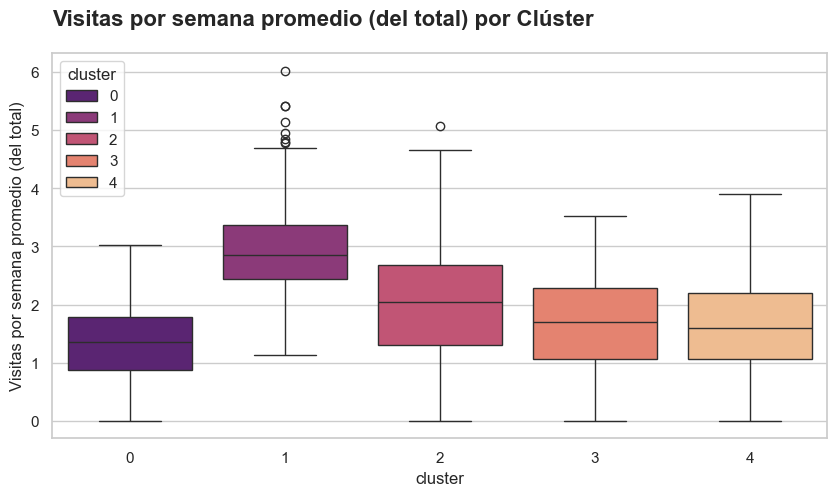

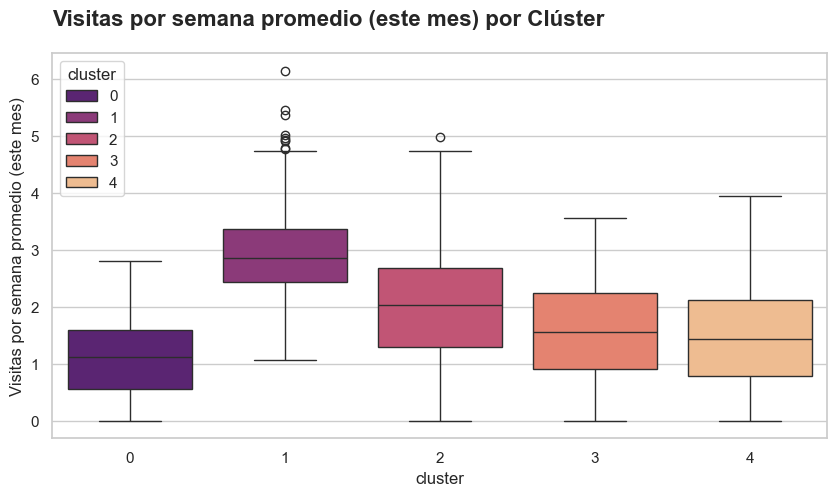

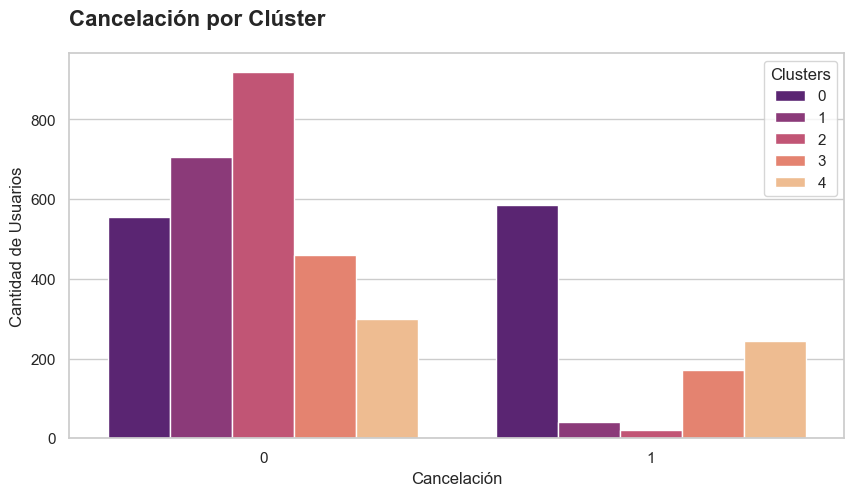

In [40]:
# Traza distribuciones de características para los clústeres
# Excluimos 'cluster' de las características
features = df.drop('cluster', axis=1).columns
colors = [color_2, color_3, color_4, color_5, color_6]

# Iterar sobre las columnas para graficar
for col in features:
    plt.figure(figsize=(10, 5))
    
    # Si la variable es binaria o tiene pocos valores, usamos un gráfico de conteo
    if df[col].nunique() <= 2:
        sns.countplot(x=col, hue='cluster', data=df, palette=colors)
        plt.title(f'{chart_name[col]} por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('Cantidad de Usuarios')
        plt.legend(title='Clusters', loc='upper right')
    
    # Si la variable es continua, usamos un boxplot para ver la dispersión
    else:
        sns.boxplot(x='cluster', y=col, data=df, hue='cluster', palette=colors)
        plt.title(f'{chart_name[col]} por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.ylabel(f'{chart_name[col]}')

    plt.show()

Tasa de cancelación por clúster:
cluster
0    0.513181
1    0.054960
2    0.022317
3    0.269414
4    0.450368
Name: churn, dtype: float64



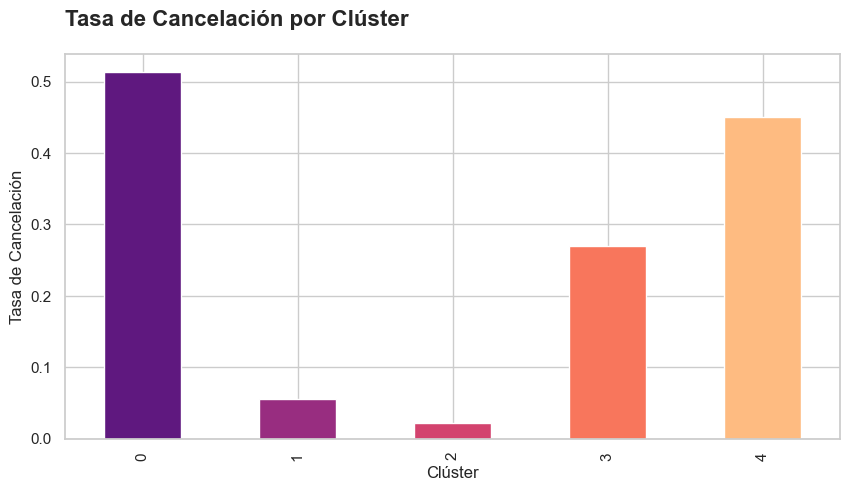

In [16]:
# Calcula la tasa de cancelación para cada clúster (groupby())
# ¿Difieren los grupos?
churn_rate = df.groupby('cluster')['churn'].mean()
print("Tasa de cancelación por clúster:")
print(churn_rate)
print()

# Graficar la tasa de cancelación
plt.figure(figsize=(10, 5))
churn_rate.plot(kind='bar', color=colors)
plt.title('Tasa de Cancelación por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.xlabel('Clúster')
plt.ylabel('Tasa de Cancelación')
plt.show()

<b>CONCLUSIONES INTERMEDIAS:</b>

Las características que se detectaron en los Clústers son las siguientes:

<b>Clúster 0 - Perfil Ejecutivo</b>

(Clientes de mayor valor):
- Tienen la tasa de cancelación más baja (2%)
- Segundo grupo con mayor cantidad de visitas promedio.
- Grupo al que le faltan mas meses para finalizar contrato.
- Grupo con altos cargos adicionales.
- Edades más altas.
- Tienen los contratos más largos (12 meses).
- Vienen de parte de una compañía asociada.
- El mayor porcentaje que usó la Promo-Amigos
- Tienen cercanía al gimnasio.

Resumen: Este perfil se distingue por mayor poder adquisitivo, pero que también aprovecha los descuentos. Edad más alta, vienen de una compañia asociada, probablemente es un perfil con mayor estabilidad ecónomica y mayor madurez, el riesgo de perder a estos clientes es el más bajo.

<b>Clúster 1 - Perfil sin Contacto</b>

(Clientes de riesgo medio):
- Visitas menos frecuentes
- Contratos de principalmente entre 1 y 6 meses.
- Edades intermedias.
- Grupo sin telefono de contacto.
- La mayortía tiene cercanía al gimnasio.

Resumen: El riesgo de cancelación de este grupo es moderado (26.75%). Su principal característica es la ausencia de telefono de contacto, en las demas caracteristicas esta a un nivel intermedio del resto de los clústeres.

<b>Clúster 2 - Perfil de mayor Distancia</b>

(Clientes de alto riesto):
- Segundo lugar en menor cantidad de visitas.
- La mayoría esta a un mes de finalizar su contrato.
- Pocos gastos adicionales al mes.
- Entre los grupos mas jóvenes.
- Menor participación en sesiones grupales.
- Principalmente contratos de 1 mes.
- El grupo que menos usa la Promo-Amigos.
- Ninguno cumple con la cercanía al gimnasio.

Resumen: Su riesgo de cancelación es alto (44%). Se caracteriza por no estar cercanos al gimansio, esto podría dificultar más las visitas y por lo tanto el compromiso con el gimnasio. También es de los grupos con contratos de menor compromiso (1 mes).

<b>Clúster 3 - Perfil Jóven/Inexperto</b>
(Clientes críticos): 
- La tasa de cancelación más alta (51.42%)
- La menor cantidad de visitas
- El grupo de menor cantidad de meses inscrito.
- Menor cantidad de meses para finalizar.
- Menor cantidad de cargos adicionales.
- El grupo más jóven.
- La menor asistencia a sesiones grupales.
- Contratos principalmente de 1 mes.
- El grupo que menos uso hace de la Promo-Amigos, o descuentos de compañias asociadas.
- Todos tienen cercanía al gimnasio.

Resumen: Se distinguen por ser el grupo más jóven, que menos gasta, pero también que menos utiliza descuentos. Se comprometen menos a contratos largos y no mostraron disciplina en la asistencia. Probablemente sea un grupo más inmaduro o inexperto en gimnasios, pero que por la cercanía hicieron el intento de inscribirse.

<b>Clúster 4 - Perfil Atlético</b>

(Clientes riesgo bajo):
- Tasa de cancelación muy baja (6%).
- Tienen la mayor cantidad de visitas por semana.
- Tienen entre 1 y 5 meses para finalizar su contrato.
- Entre los grupos con mayores gastos adicionales.
- Entre los grupos de mayor edad.
- Contratos de entre 1 y 6 meses.
- La mayoría tienen cercanía al gimnasio.

Resumen: Perfil con mayor experiencia y disciplina en el gimnasio. Probablemente no dejarán el gimnasio porque estan acostumbrados a entrenar y factores como la cercanía y servicios adicionales adquiridos los mantienen activos.

## 6. Conclusiones y Recomendaciones

Para maximizar los ingresos de la cadena de gimnasios ModelFitnes, se proponen 3 estrategias diferenciadas por el nivel de riesgo de cada Clúster.

<b>1. Estrategia de Retención Activa (Para Clúster 2 y 3):</b>
- Como el Clúster 1 es el más inexperto, una campaña de 'Coaching' durante el primer mes puede lograr atravesar la dificl barrera del primer mes, ayudar a los nuevos usuarios a generar compromiso y habito por el ejercicio.
-  Para el Clúster 2, que es el que tiene problemas por la lejanía se podrían proponer estrategias que ataquen directamente el problema de la movilidad como ofrecer promociones por hacer 'Carpool' o ofrecer algun plan de entrenamiento remoto o híbrido.
-  Para ambos grupos se debe de buscar una estrategia que convenga ambas partes para que sus contratos sean de más de un mes, ya que en los otros Clústers con menor tasa de cancelación es una característica que comparten.

<b>2. Estrategia de Actualización (Para Clúster 1):</b>
- Campaña para que registren sus números telefónicos, ya que sin datos de contacto no es posible hacer marketing de retención.
- La estrategía con este Clúster debe buscar que los usuarios asistan con mayor frecuencia a entrenar, ya que esta característica se relaciona con mayor fidelidad.

<b>3. Estrategia de Fidelización (Para Clúster 0 y 4):</b>
- El objetivo con estos usuarios es mantenerlos motivados. Como estos dos grupos muestran la mayor cantidad de gastos adicionales, se les pueden enviar ofertas exclusivas para servicios adicionales premium. Como es un perfil mas adulto, y con tendencia a invertir en servicios de gimnasio, son un grupo mas propenso a aceptar ofertas de servicios adicionales que les resulten atractivos.
- Como el Clúster 0 ya usa la Promo-Amigos, es posible que a traves de este grupo se puedan atraer mas clientes del mismo perfil, si se les ofrece alguna promoción por invitar más usuarios.